# Proyecto Final - Clasificación múltiple con Iris UCI

Este notebook descarga el dataset desde UCI, lo convierte a CSV, entrena Regresión Logística y Red Neuronal, aplica tuneo de hiperparámetros y evalúa con matriz de confusión y exactitud.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import joblib
import json
from pathlib import Path
Path('data').mkdir(exist_ok=True)
Path('model').mkdir(exist_ok=True)


In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columnas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'clase']

df = pd.read_csv(url, header=None, names=columnas)
df = df.dropna()
df.to_csv('data/iris_uci.csv', index=False)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,clase
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print('Filas y columnas:', df.shape)
print(df['clase'].value_counts())
df.describe().T

Filas y columnas: (150, 5)
clase
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [5]:
X = df.drop(columns=['clase'])
y = df['clase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (120, 4)
Prueba: (30, 4)


In [6]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000))
])

log_params = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs'],
    'model__penalty': ['l2']
}

log_search = RandomizedSearchCV(
    log_model, log_params, n_iter=5, cv=3, scoring='accuracy', random_state=42
)
log_search.fit(X_train, y_train)

print('Mejores parametros:', log_search.best_params_)
print('Mejor accuracy CV:', log_search.best_score_)

c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

Mejores parametros: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 10}
Mejor accuracy CV: 0.9583333333333334


c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [9]:
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(max_iter=2000, random_state=42))
])

mlp_params = {
    'model__hidden_layer_sizes': [(8,), (16,), (32,), (16, 8)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__solver': ['adam']
}

mlp_search = RandomizedSearchCV(
    mlp_model,
    mlp_params,
    n_iter=6,
    cv=3,
    scoring='accuracy',
    random_state=42,
    error_score='raise'
)

mlp_search.fit(X_train, y_train)

print('Mejores parametros:', mlp_search.best_params_)
print('Mejor accuracy CV:', mlp_search.best_score_)

Mejores parametros: {'model__solver': 'adam', 'model__hidden_layer_sizes': (8,), 'model__alpha': 0.01, 'model__activation': 'relu'}
Mejor accuracy CV: 0.9500000000000001



Modelo: Regresion Logistica
Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



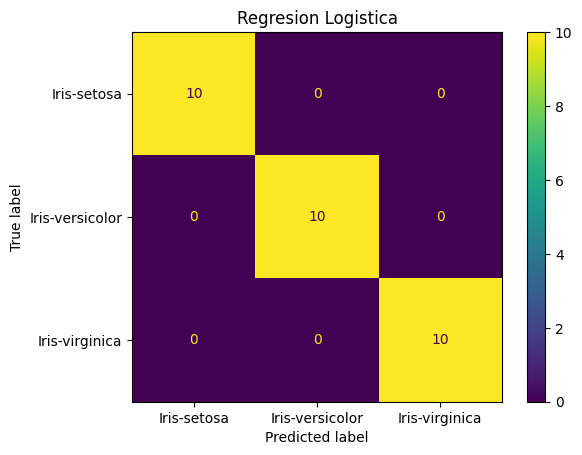


Modelo: Red Neuronal
Accuracy: 0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



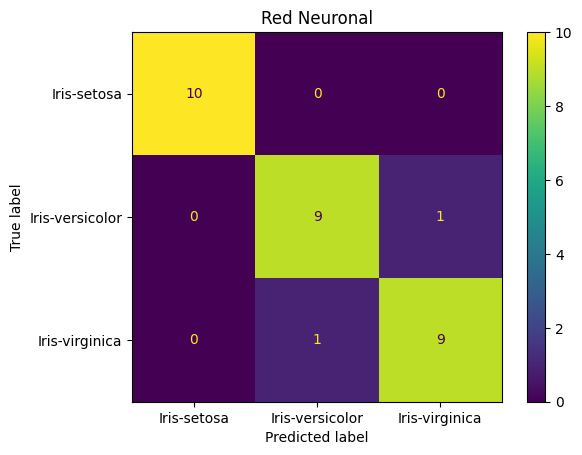

In [10]:
modelos = {
    'Regresion Logistica': log_search.best_estimator_,
    'Red Neuronal': mlp_search.best_estimator_
}

resultados = {}
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print()
    print('Modelo:', nombre)
    print('Accuracy:', acc)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(nombre)
    plt.show()

In [ ]:
mejor_nombre = max(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_nombre]
joblib.dump(mejor_modelo, 'model/best_model.joblib')

log_web = log_search.best_estimator_
scaler = log_web.named_steps['scaler']
lr = log_web.named_steps['model']
web_params = {
    'features': list(X.columns),
    'classes': list(lr.classes_),
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'coef': lr.coef_.tolist(),
    'intercept': lr.intercept_.tolist(),
    'defaults': X.median().to_dict(),
    'accuracy': float(resultados['Regresion Logistica'])
}
with open('model/logistic_web_params.json', 'w', encoding='utf-8') as f:
    json.dump(web_params, f, indent=2)

print('Mejor modelo:', mejor_nombre)
print('Archivos guardados en /model')

Mejor modelo: Regresion Logistica
Archivos guardados en /model
